# Phase 7: Baseline Machine Learning (Titanic)

**Objective:** Build a leak-proof predictive model to classify passenger survival using the statistical signals validated in Week 3.

In this notebook, we will:
1. Isolate our test data immediately to prevent data leakage.
2. Build a Scikit-Learn `Pipeline` to safely handle median imputation (for `Age`) and One-Hot Encoding.
3. Train a baseline Logistic Regression model.
4. Evaluate performance using advanced classification metrics and a confusion matrix.
5. Extract model coefficients to mathematically validate our Week 3 Chi-Square hypothesis tests (e.g., confirming `Sex` and `Pclass` as the strongest predictive drivers).

### 1. Imports & Environment Setup
We load our standard data manipulation libraries, Scikit-Learn pipeline tools, and our custom evaluation and visualization modules from the `src` directory.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from src.models.evaluator import evaluate_classification
from src.visualization.plots import plot_confusion_matrix, set_journalism_style

set_journalism_style()

### 2. Data Loading
We load the structurally cleaned dataset from Week 1-2. We will immediately drop identifiers (`PassengerId`, `Name`, `Ticket`) as they offer no baseline predictive power and can cause the model to overfit on random noise.

In [2]:
df = pd.read_csv(Path.cwd().parent.parent / "datasets" / "processed" / "titanic_cleaned.csv")
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print(f"Model-ready dataset shape: {df_clean.shape}")

Model-ready dataset shape: (889, 8)


### 3. Train/Test Split (The Data Leakage Barrier)
**Crucial Step:** In Week 3, we deferred imputing the missing `Age` values. If we impute using the median of the *entire* dataset now, data from the test set will leak into the training process. We must split the data first, and calculate the median strictly on the training set.

In [ ]:
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

# Added stratify=y to ensure 62/38 survival split is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} passengers")
print(f"Testing set size: {X_test.shape[0]} passengers")

Training set size: 711 passengers
Testing set size: 178 passengers


### 4. Pipeline Construction
We construct a `ColumnTransformer` to route our features through the correct preprocessing steps:
- **Numeric Features (`Age`, `Fare`, `SibSp`, `Parch`):** Passed through a `SimpleImputer` (median) and a `RobustScaler`.
- **Categorical Features (`Pclass`, `Sex`, `Embarked`):** Passed through a `OneHotEncoder`. We use `drop='first'` to prevent perfect multicollinearity (the Dummy Variable Trap), which is strictly required for Logistic Regression.

In [4]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked'] 

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
])

### 5. Model Definition
We attach our `LogisticRegression` estimator to the end of the preprocessing pipeline. This guarantees that calling `.predict()` on unseen data will automatically route it through the exact same scaling and imputation logic defined by the training set.

In [5]:
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

### 6. Training
We fit the entire pipeline on the isolated training set.

In [6]:
clf_pipeline.fit(X_train, y_train)
print("Pipeline trained successfully.")

Pipeline trained successfully.


### 7. Evaluation
We predict on the test set and evaluate using our custom `evaluator` module to look beyond mere accuracy, checking Precision, Recall, and the F1-Score.

--- Classification Evaluation ---
Accuracy:  0.7978
Precision: 0.7324
Recall:    0.7536
F1-Score:  0.7429
---------------------------------
Insight: The model leans toward Recall (better at catching positives, higher risk of false alarms).


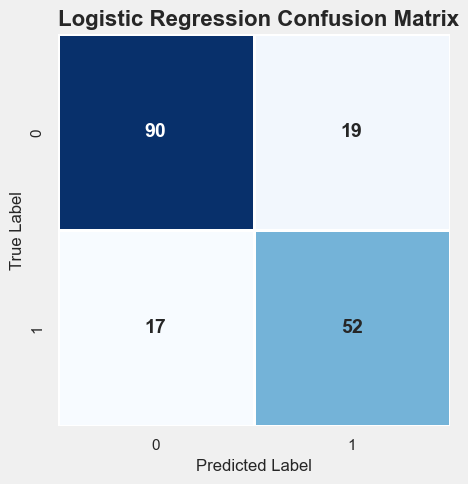

In [7]:
y_pred = clf_pipeline.predict(X_test)

evaluate_classification(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred, "Logistic Regression Confusion Matrix")

#### What do these results mean?
- **Accuracy:** The percentage of passengers we correctly classified. We must beat the Week 3 baseline of 61.8% (the accuracy of a model that simply guesses "died" for everyone).
- **Precision:** When our model predicted a passenger survived, how often were they actually right? High precision means few false positives (we didn't give false hope).
- **Recall:** Out of all the passengers who actually survived, how many did our model successfully identify? High recall means few false negatives (we didn't miss many survivors).
- **F1-Score:** The harmonic mean of Precision and Recall, providing a single metric to judge our model's balance on this imbalanced dataset.
- **Confusion Matrix:** Visually proves where our model makes mistakes. For Logistic Regression on this dataset, we often see a higher number of False Negatives (predicting a survivor died) than False Positives.

### 8. Coefficient Interpretation (The Statistical Bridge)
In Week 3, our Chi-Square test yielded a massive statistic (258.43) for `Sex`, proving it was the primary driver of survival, followed closely by `Pclass`. 

Let's extract the actual algorithmic weights from our trained Logistic Regression model to see if the Machine Learning math aligns with our Hypothesis tests.

In [8]:
classifier = clf_pipeline.named_steps['classifier']
feature_names = clf_pipeline.named_steps['preprocessor'].get_feature_names_out()

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Weight (Log Odds)': classifier.coef_[0]
})

# Sort by absolute magnitude to see the strongest drivers (positive or negative)
coefficients['Absolute Magnitude'] = coefficients['Weight (Log Odds)'].abs()
coefficients = coefficients.sort_values(by='Absolute Magnitude', ascending=False).drop(columns=['Absolute Magnitude'])

display(coefficients)

,Feature,Weight (Log Odds)
6,cat__Sex_male,-2.589166
5,cat__Pclass_3,-1.955549
4,cat__Pclass_2,-0.686746
0,num__Age,-0.560301
8,cat__Embarked_S,-0.526996
2,num__SibSp,-0.374415
7,cat__Embarked_Q,-0.084173
1,num__Fare,0.077156
3,num__Parch,-0.071009


### 9. Model Serialization & MLOps Reporting
To ensure our portfolio is production-ready, we do not let our trained models die in the notebook. 

We will serialize our `Pipeline` using `joblib` via a custom registry utility. This creates a timestamped audit trail and an alias (`latest_model.pkl`) that our API will consume in Week 7. Simultaneously, we generate an automated `.txt` training report to simulate enterprise MLOps experiment tracking.

In [9]:
from src.models.registry import save_model
from src.models.evaluator import save_training_report

# Re-run evaluation to capture the dictionary and insight
metrics, insight = evaluate_classification(y_test, y_pred, return_dict=True)

# 1. Save the serialized model artifacts
save_model(clf_pipeline, domain="titanic", model_name="logistic_regression")

# 2. Save the automated training report
save_training_report(
    domain="titanic", 
    model_name="Logistic_Regression", 
    metrics=metrics, 
    insight=insight, 
    data_shape=X_train.shape
)

--- Classification Evaluation ---
Accuracy:  0.7978
Precision: 0.7324
Recall:    0.7536
F1-Score:  0.7429
---------------------------------
Insight: The model leans toward Recall (better at catching positives, higher risk of false alarms).
Model saved successfully to C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\titanic\logistic_regression_20260729_2143.pkl
Alias updated: C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\titanic\latest_model.pkl
Training report saved to reports\runs\titanic_Logistic_Regression_20260729_2143.txt


**Conclusion:** The Machine Learning coefficients perfectly validate our Week 3 Statistical Analysis. `cat__Sex_male` holds the largest absolute negative weight, confirming that being male severely reduced the log-odds of survival. `cat__Pclass_3` holds the second largest negative weight, aligning perfectly with our Chi-Square findings regarding socio-economic status.